# Hands-On AI for Science, Aug 13 Morning: Neural Nets

This notebook is based on the notebook <a href="https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html">Learning Pytorch with Examples</a> by <a href="https://github.com/jcjohnson/pytorch-examples">Justin Johnson</a>.  I've basically copied in some of his code examples, and then added extra explanations and plots.




A **neural network** is a complicated function made up of many simple functions, some of which are parameterized.  When the network fails to perform a desired task, you might want to change the network so it does that task better.  **Back-propagation** is the process of analyzing the desired behavior change into a list of desired parameter changes.

Back-propagation is at the heart of the most popular Deep Learning Frameworks like PyTorch and Jax. This allows us to define custom methods as a composite of operations, which can be implemented iteratively using <a href="https://en.wikipedia.org/wiki/Hill_climbing">hill-climbing</a> or <a href="https://en.wikipedia.org/wiki/Gradient_descent">gradient descent</a> in order to modify the behavior of the whole network. 



In [1]:
!pip install -q numpy matplotlib

import a13pm_hw1
import importlib
import numpy as np
import matplotlib.pyplot as plt

1. [Example Problem: Polymomial Approximation of Sine](#exampleproblem)
2. [Loss Function: Mean-Squared Error](#lossfunction)
3. [Back-Propagation = Chain Rule](#backpropagation)
4. [Gradient Descent and Stochastic Gradient Descent](#gradientdescent)
5. [Training, Validation, and Testing](#training)

<a id="exampleproblem"></a>

## 1. Example Problem: Polynomial Approximation of Sine

Suppose you are trying to create software that will compute $\sin(x)$ for any value of $x$.  Suppose your computer can't compute $\sin(x)$ using a lookup table, so you must approximate $\sin(x)$ using functions that are easier to compute.  Polynomials are easy to compute: your computer has a multiplier, so it can easily compute $x^4$ by just multiplying $x$ by itself four times.  So the task you have to solve is this:  try to find coefficients $a$, $b$, $c$, and $d$ such that 

$$\sin(x)\approx a+bx+cx^2+dx^3$$

To give you an idea of the difficulty of the problem, here is a plot of $\sin(x)$ for $-\pi\le x\le \pi$:

Text(0.5, 0, 'x')

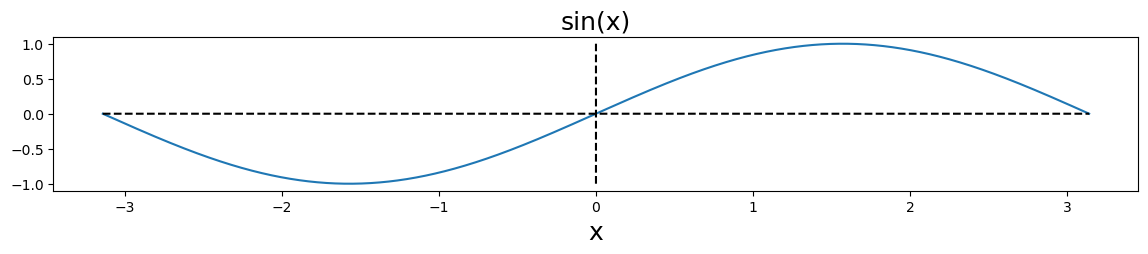

In [2]:
x = np.linspace(-np.pi, np.pi, 2000)
y = np.sin(x)
fig = plt.figure(figsize=(14,2))
ax = fig.subplots(1)
ax.plot(x,y,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-1,1),'k--')
ax.set_title('sin(x)',fontsize=18)
ax.set_xlabel('x',fontsize=18)

Your mission, should you choose to accept it, is to find coefficients $a$, $b$, $c$, and $d$ that will multiply each of the following graphs, so that when you add them together, they resemble the graph above:

Text(0.5, 1.0, '$h_3(x)=x^3$')

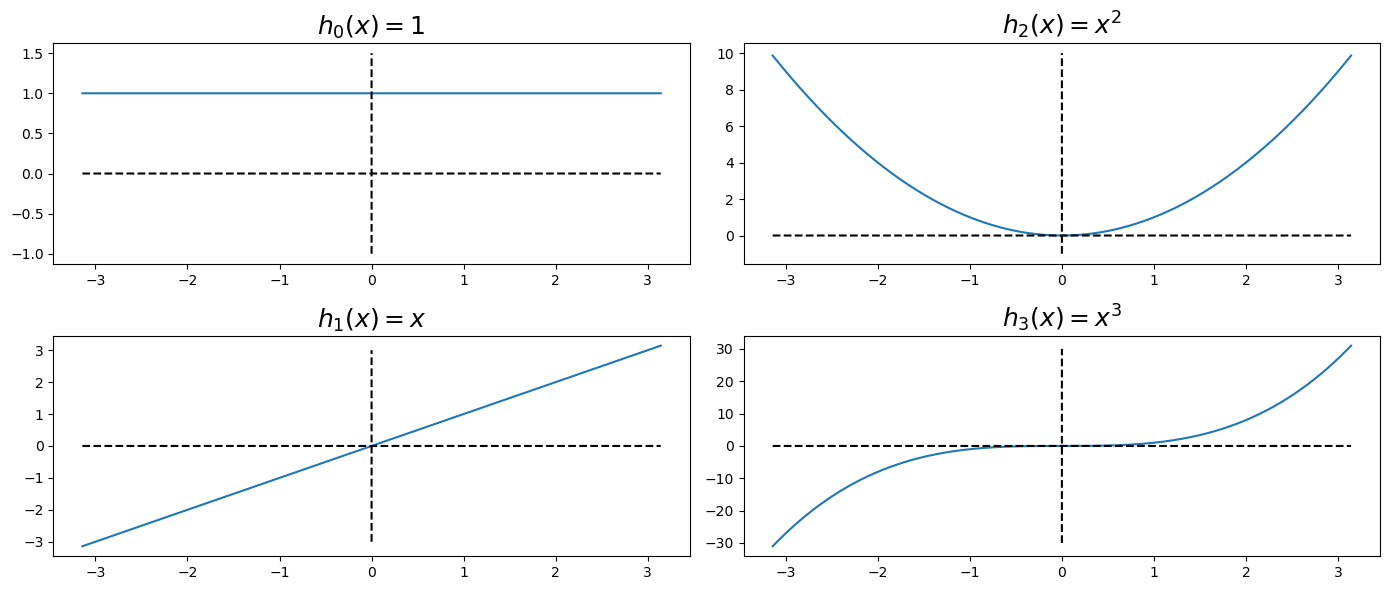

In [3]:
h0 = np.ones(len(x))
h1 = x
h2 = x**2
h3 = x**3
fig = plt.figure(figsize=(14,6),layout='tight')
axs = fig.subplots(2,2)
axs[0,0].plot(x,h0,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-1,1.5),'k--')
axs[0,0].set_title('$h_0(x)=1$',fontsize=18)
axs[1,0].plot(x,h1,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-3,3),'k--')
axs[1,0].set_title('$h_1(x)=x$',fontsize=18)
axs[0,1].plot(x,h2,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-1,10),'k--')
axs[0,1].set_title('$h_2(x)=x^2$',fontsize=18)
axs[1,1].plot(x,h3,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-30,30),'k--')
axs[1,1].set_title('$h_3(x)=x^3$',fontsize=18)


Just by looking at the plots, we can try to make a reasonable guess.  For example, suppose we guess that:

* $a=0$
* $b=1$
* $c=0$, and
* $d=-0.1$,

so our approximation is

$$f(x)=x-0.1x^3\approx \sin(x)$$

Let's see how good that is:

Text(0.5, 0, 'x')

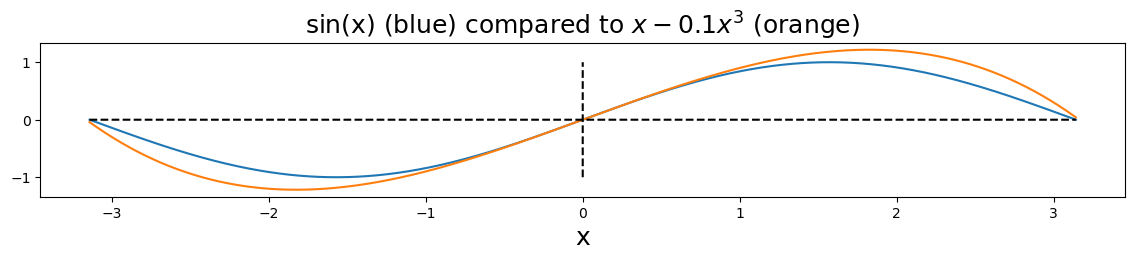

In [4]:
f = h1 - 0.1*h3

fig = plt.figure(figsize=(14,2))
ax = fig.subplots(1)
ax.plot(x,y,'-',x,f,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-1,1),'k--')
ax.set_title('sin(x) (blue) compared to $x-0.1x^3$ (orange)',fontsize=18)
ax.set_xlabel('x',fontsize=18)

That's not so bad, but it feels like we should be able to do better.  But what do we mean, exactly, by "better"?

<a id="lossfunction"></a>

## 2. Loss Function: Mean-Squared Error

The key concept in machine learning is that, in order to minimize error, you need to define very carefully what you mean by "error."  A very common and very useful definition of "error" is the loss function known as "mean-squared error" or MSE, defined as

$$\mathcal{L}=\frac{1}{N}\sum_{i=1}^{N} \left(f(x_i)-y_i\right)^2$$

where $y_i=\sin(x_i)$, and $f(x_i)$ is our neural network approximation, and $N$ is the number of training examples (in the examples we've done so far, $N=2000$).  Let's calculate the MSE of our sine wave example.

Text(0.5, 0, 'x')

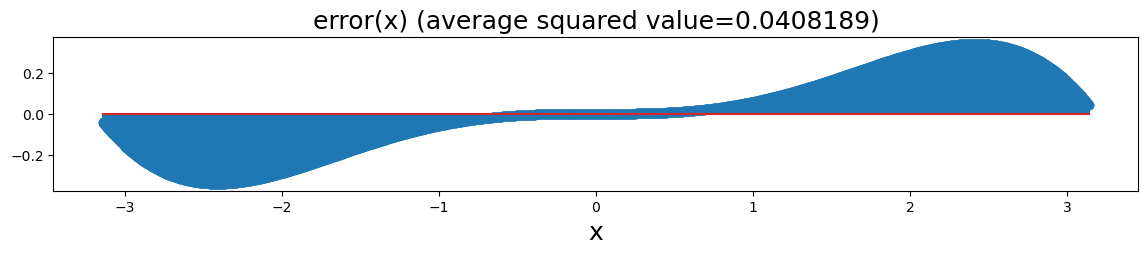

In [5]:
error = f - y
MSE = np.average(error**2)

fig = plt.figure(figsize=(14,2))
ax = fig.subplots(1)
ax.stem(x,error)
ax.set_title('error(x) (average squared value=%g)'%(MSE),fontsize=18)
ax.set_xlabel('x',fontsize=18)

That's pretty good -- the average squared error is only 0.04.  But how can we make it smaller?

<a id="backpropagation"></a>

## 3. Backpropagation = Chain Rule

If you've taken any calculus, you might remember that the values of $a$, $b$, $c$, and $d$ that minimize $\mathcal{L}$ are the ones such that

$$\frac{\partial\mathcal{L}}{\partial a}=0,~~\frac{\partial\mathcal{L}}{\partial b}=0,~~\frac{\partial\mathcal{L}}{\partial c}=0,~~\frac{\partial\mathcal{L}}{\partial d}=0$$

But how do we calculate the derivative of $\mathcal{L}$ with respect to $a$, $b$, $c$, and $d$?

The answer is the <a href="https://en.wikipedia.org/wiki/Chain_rule">chain rule</a>.  George Simmons defined the chain rule thus: "If a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car travels 2 × 4 = 8 times as fast as the man."  In other words:

1. Express the dependence of $\mathcal{L}$ on $a$, $b$, $c$ and $d$ by a series of easy steps, such that we know the derivative of each easy step, and then
2. multiply those derivatives.

That method is called <a href="https://en.wikipedia.org/wiki/Backpropagation">backpropagation</a> if each of the "easy steps" is considered to be a node in a neural network.  For example, suppose we write our neural network with the following picture, where $x_1=x_2=x$.  Suppose the left-hand node computes $x$, but the right-hand node computes $x^3$.  Then $w_1$ multiplies $x$ times $b$, and $w_2$ multiplies $x^3$ times $d$, and the final node just adds them together:


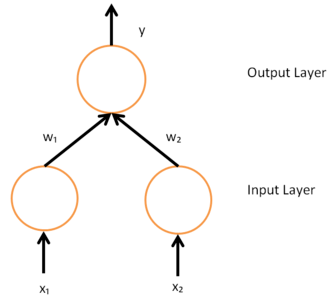


In this case, we have the following easy steps:

1. $f(x)=a+bx+cx^2+dx^3$, so the derivatives w.r.t. $a$, $b$, $c$ and $d$ are $$\frac{\partial f}{\partial a} = 1,~~\frac{\partial f}{\partial b} = x,~~\frac{\partial f}{\partial c} = x^2,~~\frac{\partial f}{\partial d} = x^3$$
2. $\epsilon = f(x)-y$, so its derivative w.r.t. $f(x)$ is $$\frac{\partial\epsilon}{\partial f} = 1$$
3. $\mathcal{L} = \frac{1}{N}\epsilon_i^2$, so it's derivative w.r.t. $\epsilon_i$ is $$\frac{\partial\mathcal{L}}{\partial\epsilon_i} = \frac{2}{N}\epsilon_i$$

Putting it all together, for all 2000 training points, we have:

$$\frac{\partial\mathcal{L}}{\partial d} = \sum_{i=1}^{2000}\frac{\partial\mathcal{L}}{\partial f_i}\cdot\frac{\partial f_i}{\partial\epsilon_i}\cdot\frac{\partial\epsilon_i}{\partial x_i}$$

Let's calculate that derivative, and the derivatives with respect to $a$, $b$, and $c$:

In [14]:
N = len(x)
dLda = np.sum((2/N) * error * 1)
print('dL/da = %g'%(dLda))
dLdb = np.sum((2/N) * error * x)
print('dL/db = %g'%(dLdb))
dLdc = np.sum((2/N) * error * x**2)
print('dL/dc = %g'%(dLdc))
dLdd = np.sum((2/N) * error * x**3)
print('dL/dd = %g'%(dLdd))



dL/da = -5.55112e-17
dL/db = 0.683158
dL/dc = -1.11022e-16
dL/dd = 3.75554


$\frac{\partial\mathcal{L}}{\partial a}$ and $\frac{\partial\mathcal{L}}{\partial c}$ are very nearly 0 already (meaning that the values $a=0$ and $c=0$ are already optimal), but $\frac{\partial\mathcal{L}}{\partial b}\ne 0$ and $\frac{\partial\mathcal{L}}{\partial d}\ne 0$.

So here's the big question: What can we do about it?  How do we choose values of $b$ and $d$ to make $\frac{\partial\mathcal{L}}{\partial b}= 0$ and $\frac{\partial\mathcal{L}}{\partial d}= 0$?

For the simple example we're working with here, this problem can be solved using pencil and paper, but for most real-world problems, a pencil-and-paper solution is not practical.  Instead, practical neural network algorithms solve this problem using stochastic gradient descent.

<a id="gradientdescent"></a>

## 4. Gradient Descent and Stochastic Gradient Descent

<a href="https://commons.wikimedia.org/wiki/File:Gradient_descent.gif">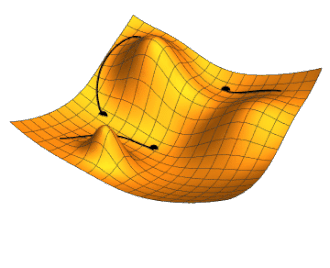</a>

Suppose that the plot above shows the MSE as a function of $a$, $b$, $c$ and $d$.  Some values of $(a,b,c,d)$ have lower errors than others.  We don't know in advance which values are best.

However, we **do** know the slopes $\frac{\partial\mathcal{L}}{\partial a},\frac{\partial\mathcal{L}}{\partial b},\frac{\partial\mathcal{L}}{\partial c},$ and $\frac{\partial\mathcal{L}}{\partial d}$.  So if we start from some randomly chosen initial values, we can improve them by **moving downhill**:

$$a\leftarrow a-0.002 \frac{\partial\mathcal{L}}{\partial a}$$
$$b\leftarrow b-0.002 \frac{\partial\mathcal{L}}{\partial b}$$
$$c\leftarrow c-0.002 \frac{\partial\mathcal{L}}{\partial c}$$
$$d\leftarrow d-0.002 \frac{\partial\mathcal{L}}{\partial d}$$

(The number 0.002 is called the "learning rate;" 0.002 is not always the best learning rate, but sometimes it is).  

Moving downhill is called <a href="https://en.wikipedia.org/wiki/Gradient_descent">gradient descent</a>.  Here is Justin Johnson's implementation of gradient descent for the polynomial sine approximation problem:

In [10]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

# Randomly initialize weights
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 0.002
for t in range(2000):
    # Forward pass: compute predicted y
    # y = a + b x + c x^2 + d x^3
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss
    loss = np.average(np.square(y_pred - y))
    if t % 100 == 0:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y) / 2000
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')


0 577.8698254592439
100 0.06257472063094889
200 0.043434595259498346
300 0.03061393427348079
400 0.022019508505245783
500 0.016253816348114174
600 0.012382780402752773
700 0.009781680005471203
800 0.008032421191324505
900 0.006855002886907003
1000 0.0060617718132445104
1100 0.005526871290413643
1200 0.005165825372011519
1300 0.004921887496172782
1400 0.004756906422356112
1500 0.0046452105363549295
1600 0.004569510209997912
1700 0.004518150280158162
1800 0.00448326639059567
1900 0.00445954686551813
Result: y = 0.006190978928240318 + 0.8509333556881346 x + -0.0010680468834554909 x^2 + -0.09250432453203525 x^3


Notice that:

* This code starts with random initial values for $a$, $b$, $c$, and $d$
* Therefore, in iteration 0, the loss is huge!
* By iteration 100, the loss is already pretty small...
* After 2000 iterations, the loss is only about 0.004 -- very small indeed.

Let's see how the fit looks:

Text(0.5, 0, 'x')

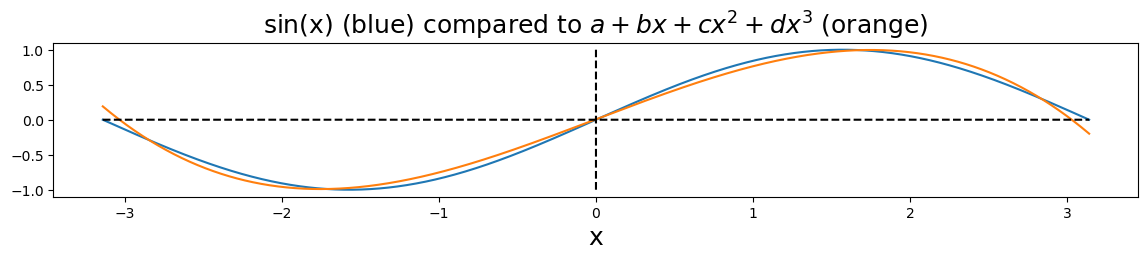

In [11]:
fig = plt.figure(figsize=(14,2))
ax = fig.subplots(1)
ax.plot(x,y,'-',x,y_pred,'-',x,np.zeros(len(x)),'k--',(-1e-6,1e-6),(-1,1),'k--')
ax.set_title('sin(x) (blue) compared to $a+bx+cx^2+dx^3$ (orange)',fontsize=18)
ax.set_xlabel('x',fontsize=18)

### 4.1 Stochastic Gradient Descent

On the internet, there is too much data... 

So in the real world, you would never use the whole training dataset in every iteration.  Instead, the most common strategy is <a href="https://en.wikipedia.org/wiki/Stochastic_gradient_descent">stochastic gradient descent</a>, where the word **stochastic** refers to the random selection of training samples in each iteration:

1. Choose a random set of $M$ training examples, called the "minibatch"
2. Compute the neural net's loss using only those $M$ training examples
3. Update the neural net's parameters by just one gradient step
4. Repeat from step 1

For example, here is stochastic gradient descent using $M=100$:

In [17]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

# Randomly initialize weights
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 0.002
batch_size = 100  # M = batch size

for t in range(40000):
    which_tokens = np.random.randint(low=0, high=1999, size=batch_size)
        
    # Forward pass: compute predicted y
    # y = a + b x + c x^2 + d x^3
    y_pred = a + b * x[which_tokens] + c * x[which_tokens] ** 2 + d * x[which_tokens] ** 3

    # Compute and print loss
    loss = np.average(np.square(y_pred - y[which_tokens]))
    if t % 2000 == 0:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y[which_tokens]) / batch_size
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x[which_tokens]).sum()
    grad_c = (grad_y_pred * x[which_tokens] ** 2).sum()
    grad_d = (grad_y_pred * x[which_tokens] ** 3).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')


0 192.17288526379966
2000 0.005095432895791891
4000 0.004048347718757467
6000 0.0037883677135926693
8000 0.004023097916011313
10000 0.005300349429282275
12000 0.004449731597441007
14000 0.004697084279550642
16000 0.0037506429289362836
18000 0.0051768033784783275
20000 0.004198280727133092
22000 0.003950752316704193
24000 0.005143600889784868
26000 0.0037806564558585244
28000 0.004431086127358655
30000 0.004653422343171595
32000 0.004771735704528197
34000 0.004433655636962798
36000 0.0034444770621478164
38000 0.005201984079521435
Result: y = 0.0004497862953775691 + 0.856535504096606 x + -0.00029343898179551477 x^2 + -0.09386913081523326 x^3


<a id="training"></a>

## 5. Training, Validation, and Testing